In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import regionmask

In [2]:
# setup
processed_dir = '../data/FASTMIP_phase2/METEOR_emulations/processed/'
ESM_list = ['ACCESS-ESM1-5','CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'MIROC6']  #(Tier 1 list)
scenario_list = ['Low - SSP2 (Marker)','Medium - SSP2 (Marker)','High - SSP3 (Marker)','Very Low - SSP1 (Marker)']
scenarios_short = ['L','M','H','VL']

# model, scenario, and grid-cell selection for plotting:
model = 'ACCESS-ESM1-5'
s_idx = 0 
sel_lat = 46.25
sel_lon = 3.75

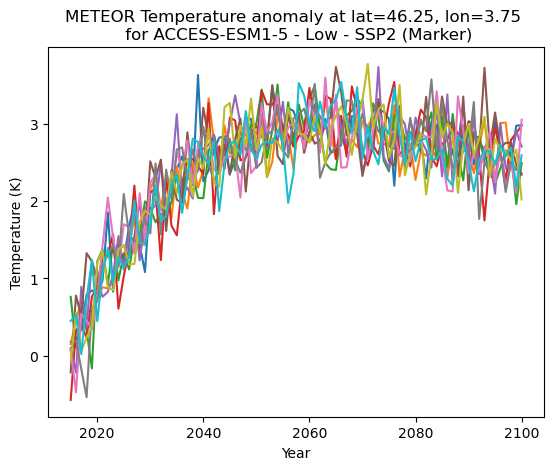

In [3]:
# plot ensemble timeseries for a given point:
tas = xr.open_dataset(f"{processed_dir}/tas_{scenarios_short[s_idx]}_METEOR_gridcell_selected-realisations.nc")

plt.figure()
plt.plot(tas['year'].values, tas['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values)
plt.xlabel('Year')
plt.ylabel('Temperature (K)') 
plt.title(f'METEOR Temperature anomaly at lat={sel_lat}, lon={sel_lon} \n for {model} - {scenario_list[s_idx]}')
plt.show()
#plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_{sel_lat}_{sel_lon}.png")

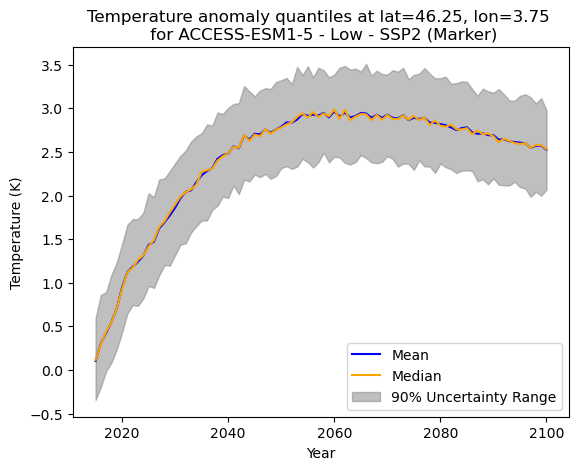

In [31]:
# plotting the median and mean temperature anomaly
# along with the 90% uncertainty range for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/tas_{scenarios_short[s_idx]}_METEOR_gridcell_quantiles-by-ESM.nc")

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values.squeeze(),
                 example_data['tas'].sel(esm=model).sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values.squeeze(),
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles at lat={sel_lat}, lon={sel_lon} \n for {model} - {scenario_list[s_idx]}')
plt.legend()
plt.show()
#plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_quantiles_{sel_lat}_{sel_lon}.png")

/storage/no-backup-nac/users/maurad/METEOR/fastmip_env/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


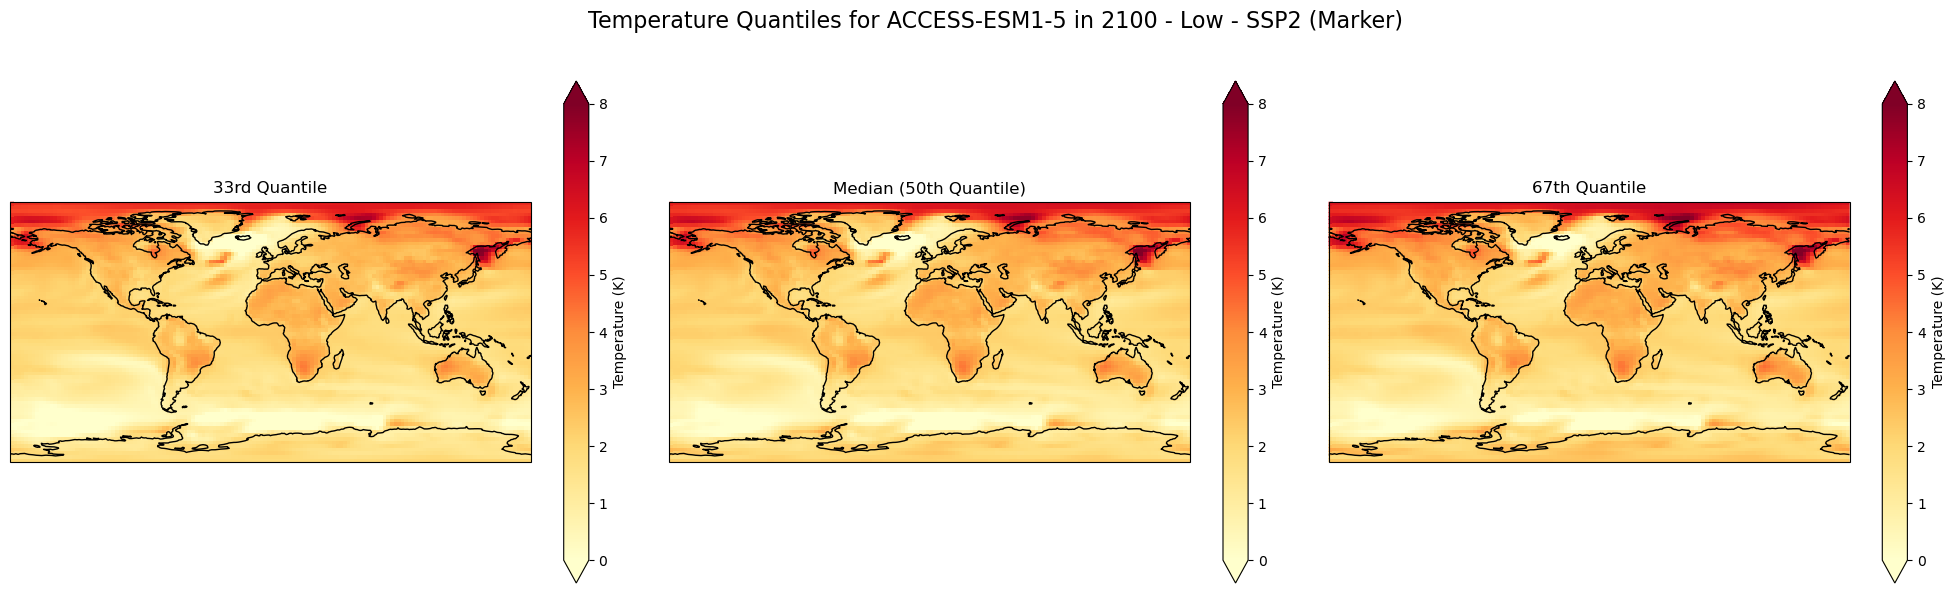

In [6]:
# Generate maps for the 33rd, median, and 67th quantiles for the selected ESM and year 2100

quantiles_to_plot = [0.33, 0.5, 0.67]
titles = ['33rd Quantile', 'Median (50th Quantile)', '67th Quantile']
cmap = 'YlOrRd'

fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, quantile, title in zip(axes, quantiles_to_plot, titles):
    data = example_data['tas'].sel(quantile=quantile, esm=model, year=2100)
    data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        cbar_kwargs={"label": "Temperature (K)"},
        vmin = 0,
        vmax = 8
    )
    ax.coastlines()
    ax.set_title(title)

fig.suptitle(f'Temperature Quantiles for {model} in 2100 - {scenario_list[s_idx]}', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the suptitle
plt.show()
#plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_quantile_maps_2100.png")

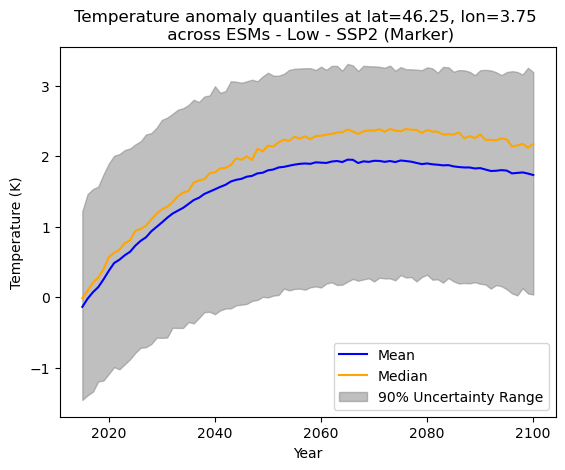

In [12]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range computed across ESMs
# for the selected grid-cell
example_data = xr.open_dataset(f"{processed_dir}/tas_{scenarios_short[s_idx]}_METEOR_gridcell_quantiles-across-ESM.nc")

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(lat=sel_lat, lon=sel_lon, method='nearest').values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(lat=sel_lat, lon=sel_lon, quantile=0.5, method='nearest').values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(lat=sel_lat, lon=sel_lon, quantile=0.05, method='nearest').values,
                 example_data['tas'].sel(lat=sel_lat, lon=sel_lon, quantile=0.95, method='nearest').values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles at lat={sel_lat}, lon={sel_lon} \n across ESMs - {scenario_list[s_idx]}')
plt.legend()
plt.show()
#plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_tasanom_quantiles_{sel_lat}_{sel_lon}.png")

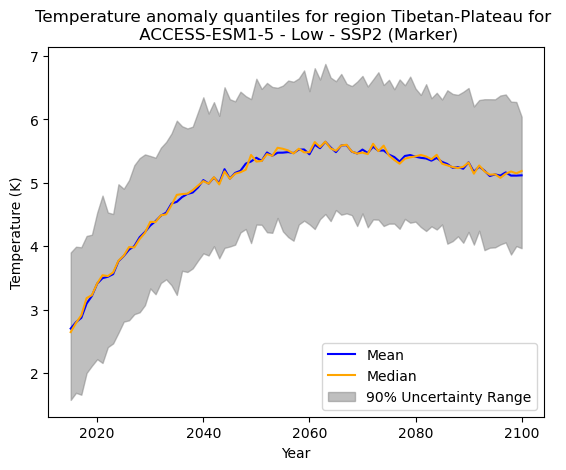

In [10]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# and ESM
example_data = xr.open_dataset(f"{processed_dir}/tas_{scenarios_short[s_idx]}_METEOR_regional_quantiles-by-ESM.nc")
selected_regions = [-1, 34, 17]
sel_mask = selected_regions[1]  # selecting a region
region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(mask = sel_mask, esm = model ).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(mask = sel_mask, quantile=0.5, esm = model ).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.05, esm = model ).values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.95, esm = model ).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles for region {region_name} for \n {model} - {scenario_list[s_idx]}')
plt.legend()
plt.show()
#plt.savefig(f"../figures/METEOR_{model}_{scenarios_short[s_idx]}_tasanom_quantiles_region{region_name}.png")

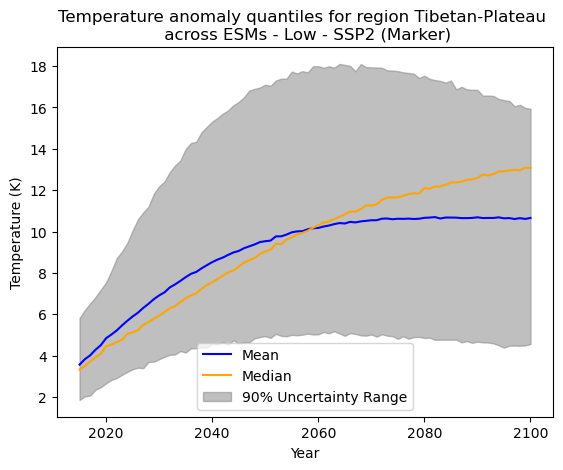

In [11]:
# plot the median and mean temperature anomaly
# along with the 90% uncertainty range for a selected region
# across ESMs
example_data = xr.open_dataset(f"{processed_dir}/tas_{scenarios_short[s_idx]}_METEOR_regional_quantiles-across-ESM.nc")
sel_mask = selected_regions[1]  # selecting a region
region_name = regionmask.defined_regions.ar6.land[sel_mask].name # getting the name of the region

plt.figure()
plt.plot(example_data['year'].values, example_data['tas_mean'].sel(mask = sel_mask).values, label='Mean', color='blue')
plt.plot(example_data['year'].values, example_data['tas'].sel(mask = sel_mask, quantile=0.5).values, label='Median', color='orange')
plt.fill_between(example_data['year'].values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.05).values,
                 example_data['tas'].sel(mask = sel_mask, quantile=0.95).values,
                 color='gray', alpha=0.5, label='90% Uncertainty Range')
plt.xlabel('Year')
plt.ylabel('Temperature (K)')  # Assuming the data is temperature in Kelvin
plt.title(f'Temperature anomaly quantiles for region {region_name} \n across ESMs - {scenario_list[s_idx]}')
plt.legend()
plt.show()
#plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_tasanom_quantiles_region{region_name}.png")

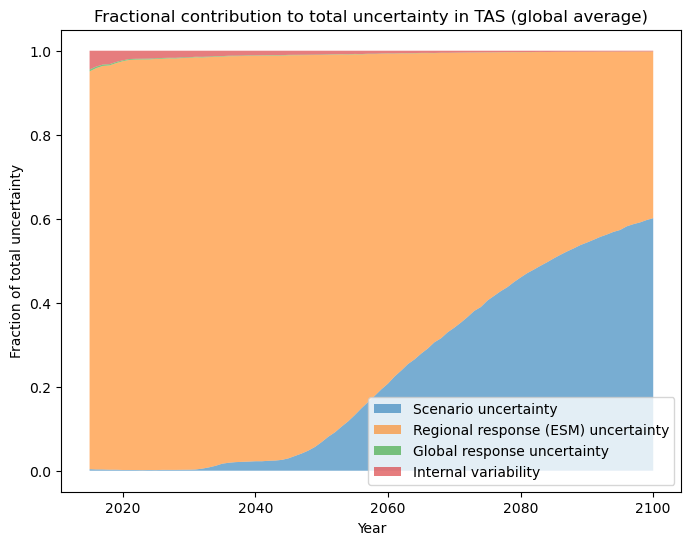

In [5]:
# plot across-scenario uncertainty
u_regional_df = xr.open_dataset(f"{processed_dir}/tas_cross-scenario_METEOR_regional_across-scenario-uncertainty.nc")
# computing the total variance as the sum of the individual variances
u_regional_df['var_total'] = u_regional_df['var_scenario'] + u_regional_df['var_esm'] + u_regional_df['var_glb'] + u_regional_df['var_int']

sel_region = -1  # global
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_glb'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in TAS (global average)')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()
#plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_uncertainty_decomposition_region{region_name}.png")

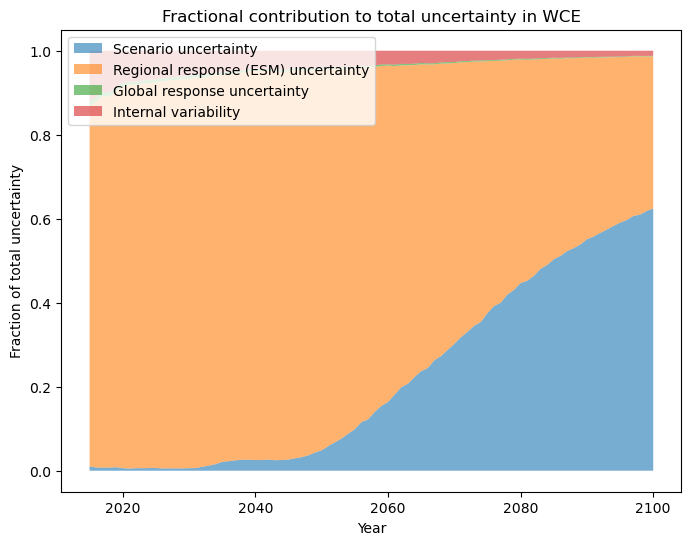

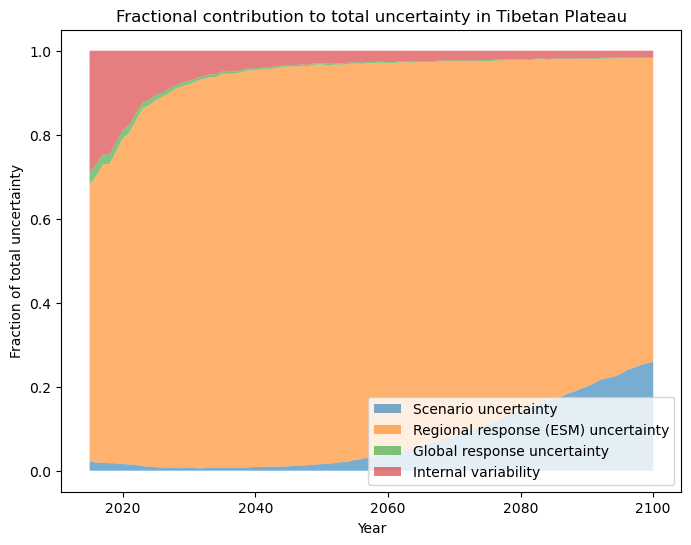

In [6]:
# the resulting plot can vary by region and in, particular,
# the smallter the region, the larger the contribution of internal variability
sel_region = 17  # CENTRAL EUROPE
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_glb'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in WCE')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'upper left')
plt.show()
#plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_uncertainty_decomposition_region{region_name}.png")

sel_region = 34  # Tibetan Plateau
plt.figure(figsize=(8, 6))

# Calculate fractional contributions
scenario_uncertainty = u_regional_df['var_scenario'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
esm_uncertainty = u_regional_df['var_esm'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
glob_uncertainty = u_regional_df['var_glb'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)
int_uncertainty = u_regional_df['var_int'].sel(mask=sel_region) / u_regional_df['var_total'].sel(mask=sel_region)

# Stack the uncertainties
plt.fill_between(u_regional_df['year'], 0, scenario_uncertainty, label='Scenario uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty, scenario_uncertainty + esm_uncertainty, label='Regional response (ESM) uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty, scenario_uncertainty + esm_uncertainty + glob_uncertainty, label='Global response uncertainty', alpha=0.6)
plt.fill_between(u_regional_df['year'], scenario_uncertainty + esm_uncertainty + glob_uncertainty, 1, label='Internal variability', alpha=0.6)

# Add labels and title
plt.title('Fractional contribution to total uncertainty in Tibetan Plateau')
plt.ylabel('Fraction of total uncertainty')
plt.xlabel('Year')
plt.legend(loc = 'lower right')
plt.show()
#plt.savefig(f"../figures/METEOR_cross-ESM_{scenarios_short[s_idx]}_uncertainty_decomposition_region{region_name}.png")